In [1]:
!pip install numpy


In [2]:
!pip install pandas

In [3]:
!pip install seaborn matplotlib
!pip install scikit-learn

In [4]:
!pip install imbalanced-learn

In [7]:
!pip install tqdm
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 3.1 MB/s eta 0:00:0000:0100:01


In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate
from sklearn import preprocessing
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.ensemble import VotingClassifier
from rdkit import Chem
from rdkit.Chem import MACCSkeys

In [9]:
def cf(cm):
    plt.rcParams["figure.figsize"] = (7, 5)
    cm_matrix = pd.DataFrame(data=cm, 
                             columns=['0', '1'], 
                             index=['0', '1'])
    sns.heatmap(cm_matrix.astype('int'), annot=True, cmap='Greens', fmt="d", 
               xticklabels=['NRB', 'RB'], yticklabels=['NRB', 'RB'], annot_kws={"size": 20})
    plt.tick_params(left=False, bottom=False)
    plt.xlabel('Predicted Class', fontsize=25)
    plt.xticks(fontsize=18)
    plt.ylabel('True Class', fontsize=25)
    plt.yticks(fontsize=18)
    plt.yticks(rotation=0) 
    plt.show()

In [10]:
seed = 2021

In [11]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import AllChem

In [12]:
def ensemb(vot='soft', pca=True, fp=True, scaling=True, 
           undersampling=False, seed=123, test=0.2):
    
    df = pd.read_csv('All-Public_dataset_Mordred.csv')
    df = df.fillna(0)
    
    
    svm = SVC(C=1, gamma=0.001, kernel='rbf', probability=True)
    rf = RandomForestClassifier(max_depth=8, min_samples_leaf=8, min_samples_split=16, n_estimators=100)
    gb = GradientBoostingClassifier(learning_rate=0.1, max_depth=4, n_estimators=75, subsample=0.7)
    
    votingC = VotingClassifier(estimators=[('svm', svm),
                                           ('rf',rf), 
                                           ('gb', gb)], voting=vot, n_jobs=-1)
    if fp:
        
        from rdkit.Chem import rdMolDescriptors
        from rdkit.Chem import AllChem

        molfps = []
        generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)  # Use the new API MorganGenerator

        for i in range(df.shape[0]):
    
            mol = Chem.MolFromSmiles(df['SMILES'].iloc[i])
            if mol is not None:
            
                fp_vect = list(generator.GetFingerprint(mol))  # This returns a list of 0s and 1s directly
                molfps.append(fp_vect)
            else:
                molfps.append([0]*2048)  # Safe fallback in case SMILES fails

        df['Fingerprint'] = molfps

        x = df.iloc[:, 2:-1].to_numpy()

        if pca:
            p = PCA(n_components=4)
            x = p.fit_transform(x)

        X = []
        for i in range(x.shape[0]):
            X.append(np.concatenate((x[i, :], np.array(df['Fingerprint'].iloc[i]))))
    if not fp:
        X = df.iloc[:, 2:].to_numpy()
    
    if scaling:
        X = preprocessing.StandardScaler().fit_transform(X)

    X = np.array(X)
    y = df['Class'].to_numpy()

    if undersampling:
        print('Undersampling...')
        X, y = RandomUnderSampler(random_state=seed).fit_resample(X, y)
    
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test, shuffle=True, stratify=y, random_state=seed)
    
    votingC.fit(x_train, y_train)
    y_pred = votingC.predict(x_test)
    
    ba = balanced_accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test.tolist(), y_pred)
    sn = cm[1,1]/(cm[1,1]+cm[1,0])
    sp = cm[0,0]/(cm[0,0]+cm[0,1])
    er = (cm[0,1]+cm[1,0])/sum(sum(cm))    
    
    return ba, sn, sp, er, cm

In [13]:
def prepro(model, pca=False, scaling=True):
    
    df = pd.read_csv('All-Public_dataset_Mordred.csv')
    df = df.fillna(0)
    

    if model == 'SVM':
        clf = SVC(C=1, gamma=0.001, kernel='rbf')
    elif model == 'RF':
        clf = RandomForestClassifier(max_depth=8, min_samples_leaf=8, min_samples_split=16, n_estimators=100)
    elif model == 'GB':
        clf = GradientBoostingClassifier(learning_rate=0.1, max_depth=4, n_estimators=75, subsample=0.7)

    molfps = []
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)  # Use MorganGenerator

    for i in range(df.shape[0]):
        mol = Chem.MolFromSmiles(df['SMILES'].iloc[i])
        if mol is not None:
            
            fp_vect = list(generator.GetFingerprint(mol))  # GetFingerprint gives 0/1 list directly
            molfps.append(fp_vect)
        else:
            molfps.append([0]*2048)  # fallback if SMILES fails

    df['Fingerprint'] = molfps

    x = df.iloc[:, 2:-1].to_numpy()

    X = []
    for i in range(x.shape[0]):
        X.append(np.concatenate((x[i,:], np.array(df['Fingerprint'].iloc[i]))))

    X = np.array(X)
    if scaling:
        X = preprocessing.StandardScaler().fit_transform(X)
    y = df['Class'].to_numpy()
    
    return clf, X, y
        


In [21]:
def predict(clf, X, y, seed=123, test=0.2, undersampling=False):
    
    if undersampling:
        X, y = RandomUnderSampler(random_state=seed).fit_resample(X, y)
    
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test, shuffle=True, stratify=y, random_state=seed)
    
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    
    ba = balanced_accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test.tolist(), y_pred)
    sn = cm[1,1]/(cm[1,1]+cm[1,0])
    sp = cm[0,0]/(cm[0,0]+cm[0,1])
    er = (cm[0,1]+cm[1,0])/sum(sum(cm))

    return ba, sn, sp, er , cm

In [22]:
from tqdm import tqdm

  0%|                                                                                                                                                                                 | 0/2 [00:00<?, ?it/s]

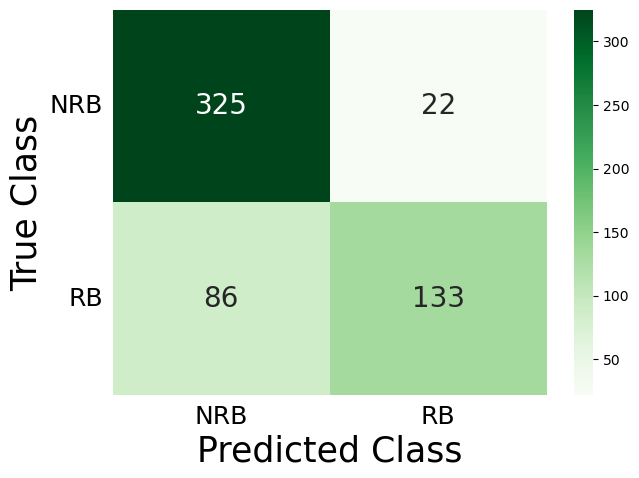

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [03:00<00:00, 90.48s/it]

CPU times: user 3min 6s, sys: 595 ms, total: 3min 6s
Wall time: 3min 7s


In [25]:
%%time
clf, X, y = prepro('SVM')

svm_ba_list = []
svm_sn_list = []
svm_sp_list = []
svm_er_list = []
for t in tqdm([0.2, 0.8]):
    ba_list = []
    sn_list = []
    sp_list = []
    er_list = []
    for r in range(0, 100, 10):
        ba, sn, sp, er, cm = predict(clf, X, y, seed=r, test=t)

        if t == 0.2 and r == 0:
            cf(cm)  # Draw heatmap only when test=0.2 and seed=0
        
        ba_list.append(ba)
        sn_list.append(sn)
        sp_list.append(sp)
        er_list.append(er)
    svm_ba_list.append(ba_list)
    svm_sn_list.append(sn_list)
    svm_sp_list.append(sp_list)
    svm_er_list.append(er_list)

  0%|                                                                                                                                                                                 | 0/2 [00:00<?, ?it/s]

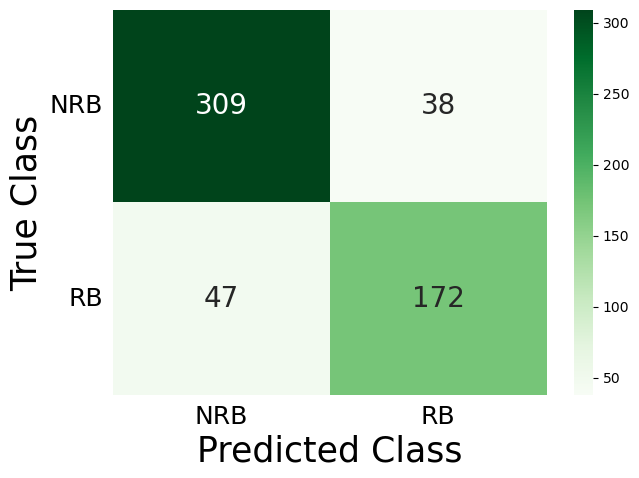

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:25<00:00, 12.77s/it]

CPU times: user 31.3 s, sys: 447 ms, total: 31.8 s
Wall time: 31.8 s


In [26]:
%%time
clf, X, y = prepro('RF')

rf_ba_list = []
rf_sn_list = []
rf_sp_list = []
rf_er_list = []
for t in tqdm([0.2, 0.8]):
    ba_list = []
    sn_list = []
    sp_list = []
    er_list = []
    for r in range(0, 100, 10):
        ba, sn, sp, er, cm = predict(clf, X, y, seed=r, test=t)
        
        if t == 0.2 and r == 0:
            cf(cm)  # Draw heatmap only when test=0.2 and seed=0
        
        
        ba_list.append(ba)
        sn_list.append(sn)
        sp_list.append(sp)
        er_list.append(er)
    rf_ba_list.append(ba_list)
    rf_sn_list.append(sn_list)
    rf_sp_list.append(sp_list)
    rf_er_list.append(er_list)

  0%|                                                                                                                                                                                 | 0/2 [00:00<?, ?it/s]

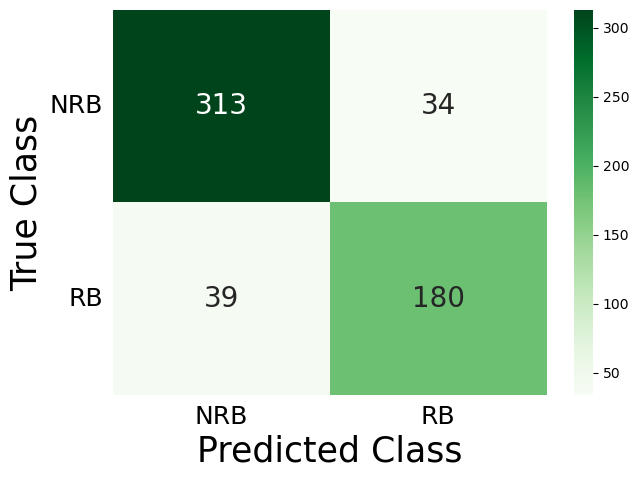

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [10:22<00:00, 311.02s/it]

CPU times: user 10min 26s, sys: 523 ms, total: 10min 26s
Wall time: 10min 28s


In [27]:
%%time
clf, X, y = prepro('GB')

gb_ba_list = []
gb_sn_list = []
gb_sp_list = []
gb_er_list = []
for t in tqdm([0.2,0.8]):
    ba_list = []
    sn_list = []
    sp_list = []
    er_list = []
    for r in range(0, 100, 10):
        ba, sn, sp, er, cm = predict(clf, X, y, seed=r, test=t)

        if t == 0.2 and r == 0:
            cf(cm)  # Draw heatmap only when test=0.2 and seed=0
        

        
        ba_list.append(ba)
        sn_list.append(sn)
        sp_list.append(sp)
        er_list.append(er)
    gb_ba_list.append(ba_list)
    gb_sn_list.append(sn_list)
    gb_sp_list.append(sp_list)
    gb_er_list.append(er_list)

  0%|                                                                                                                                                                                 | 0/2 [00:00<?, ?it/s]

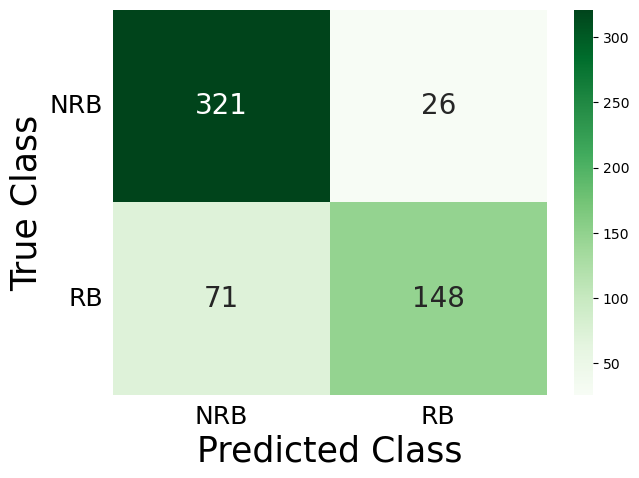

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [08:31<00:00, 255.52s/it]

CPU times: user 3min 55s, sys: 8.02 s, total: 4min 3s
Wall time: 8min 31s


In [28]:
%%time

enso_ba_list = []
enso_sn_list = []
enso_sp_list = []
enso_er_list = []
for t in tqdm([0.2, 0.8]):
    ba_list = []
    sn_list = []
    sp_list = []
    er_list = []
    for r in range(0, 100, 10):
        ba, sn, sp, er, cm = ensemb(vot='hard', seed=r, test=t)

        if t == 0.2 and r == 0:
            cf(cm)  # Draw heatmap only when test=0.2 and seed=0

        ba_list.append(ba)
        sn_list.append(sn)
        sp_list.append(sp)
        er_list.append(er)
    enso_ba_list.append(ba_list)
    enso_sn_list.append(sn_list)
    enso_sp_list.append(sp_list)
    enso_er_list.append(er_list)

In [40]:
results_df = pd.DataFrame({'SVM_BA':svm_ba_list, 'SVM_Sn':svm_sn_list, 'SVM_Sp':svm_sp_list, 'SVM_ER':svm_er_list, 
                           'RF_BA':rf_ba_list, 'RF_Sn':rf_sn_list, 'RF_Sp':rf_sp_list, 'RF_ER':rf_er_list, 
                           'GB_BA':gb_ba_list, 'GB_Sn':gb_sn_list, 'GB_Sp':gb_sp_list, 'GB_ER':gb_er_list, 
                           'ENSO_BA':enso_ba_list, 'ENSO_Sn':enso_sn_list, 'ENSO_Sp':enso_sp_list, 'ENSO_ER':enso_er_list})
results_df

,SVM_BA,SVM_Sn,SVM_Sp,SVM_ER,RF_BA,RF_Sn,RF_Sp,RF_ER,GB_BA,GB_Sn,GB_Sp,GB_ER,ENSO_BA,ENSO_Sn,ENSO_Sp,ENSO_ER
0,"[0.7719526798520917, 0.7545300225020726, 0.752...","[0.6073059360730594, 0.5753424657534246, 0.543...","[0.9365994236311239, 0.9337175792507204, 0.962...","[0.19081272084805653, 0.2049469964664311, 0.19...","[0.837939020699275, 0.8173910754937954, 0.8209...","[0.7853881278538812, 0.7442922374429224, 0.716...","[0.8904899135446686, 0.8904899135446686, 0.925...","[0.1501766784452297, 0.16607773851590105, 0.15...","[0.8619675496427301, 0.8451436316502836, 0.826...","[0.821917808219178, 0.7853881278538812, 0.7214...","[0.9020172910662824, 0.9048991354466859, 0.930...","[0.12897526501766785, 0.1413427561837456, 0.15...","[0.8172594844261971, 0.795027173555459, 0.7799...","[0.7123287671232876, 0.6621004566210046, 0.611...","[0.9221902017291066, 0.9279538904899135, 0.948...","[0.15901060070671377, 0.17491166077738515, 0.1..."
1,"[0.7202664457789743, 0.7205137939762085, 0.715...","[0.5011389521640092, 0.49658314350797267, 0.47...","[0.9393939393939394, 0.9444444444444444, 0.953...","[0.23056537102473498, 0.22924028268551236, 0.2...","[0.8070281401716481, 0.7624002800540386, 0.788...","[0.7403189066059226, 0.6503416856492027, 0.687...","[0.8737373737373737, 0.8744588744588745, 0.889...","[0.17800353356890458, 0.2124558303886926, 0.18...","[0.823089337895716, 0.8002716721395537, 0.8047...","[0.755125284738041, 0.715261958997722, 0.72209...","[0.8910533910533911, 0.8852813852813853, 0.887...","[0.16166077738515902, 0.18065371024734983, 0.1...","[0.7776495840277161, 0.763428295318956, 0.7723...","[0.6252847380410023, 0.6264236902050114, 0.608...","[0.93001443001443, 0.9004329004329005, 0.93650...","[0.1881625441696113, 0.2058303886925795, 0.190..."


In [41]:
print(results_df)

                                              SVM_BA  \
0  [0.7719526798520917, 0.7545300225020726, 0.752...   
1  [0.7202664457789743, 0.7205137939762085, 0.715...   

                                              SVM_Sn  \
0  [0.6073059360730594, 0.5753424657534246, 0.543...   
1  [0.5011389521640092, 0.49658314350797267, 0.47...   

                                              SVM_Sp  \
0  [0.9365994236311239, 0.9337175792507204, 0.962...   
1  [0.9393939393939394, 0.9444444444444444, 0.953...   

                                              SVM_ER  \
0  [0.19081272084805653, 0.2049469964664311, 0.19...   
1  [0.23056537102473498, 0.22924028268551236, 0.2...   

                                               RF_BA  \
0  [0.837939020699275, 0.8173910754937954, 0.8209...   
1  [0.8070281401716481, 0.7624002800540386, 0.788...   

                                               RF_Sn  \
0  [0.7853881278538812, 0.7442922374429224, 0.716...   
1  [0.7403189066059226, 0.6503416856492027,

In [42]:
results_df.to_csv('model_results.csv', index=False)


In [43]:
results_df.to_excel('model_results.xlsx', index=False)


  0%|                                                                                                                                                                                 | 0/2 [00:00<?, ?it/s]

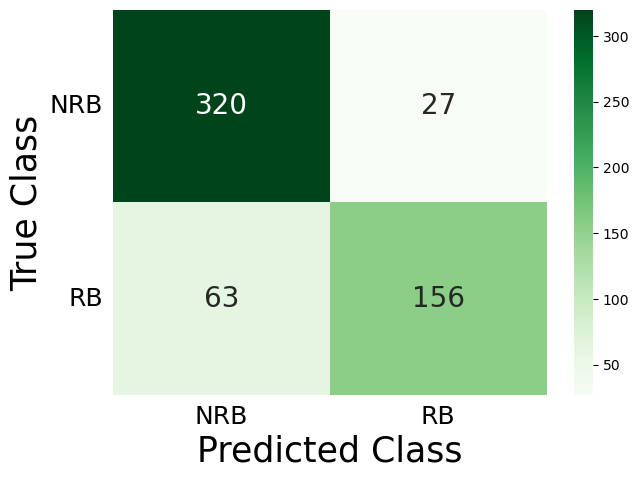

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [08:36<00:00, 258.16s/it]

CPU times: user 3min 53s, sys: 7.3 s, total: 4min 1s
Wall time: 8min 36s


In [31]:
%%time

enso_ba_list = []
enso_sn_list = []
enso_sp_list = []
enso_er_list = []
for t in tqdm([0.2, 0.8]):
    ba_list = []
    sn_list = []
    sp_list = []
    er_list = []
    for r in range(0, 100, 10):
        ba, sn, sp, er, cm = ensemb(vot='soft', seed=r, test=t)

        if t == 0.2 and r == 0:
            cf(cm)  # Draw heatmap only when test=0.2 and seed=0

        ba_list.append(ba)
        sn_list.append(sn)
        sp_list.append(sp)
        er_list.append(er)
    enso_ba_list.append(ba_list)
    enso_sn_list.append(sn_list)
    enso_sp_list.append(sp_list)
    enso_er_list.append(er_list)

In [44]:
results_df1 = pd.DataFrame({'ENSO_BA':enso_ba_list, 'ENSO_Sn':enso_sn_list, 'ENSO_Sp':enso_sp_list, 'ENSO_ER':enso_er_list})

In [45]:
print(results_df1)

                                             ENSO_BA  \
0  [0.8172594844261971, 0.795027173555459, 0.7799...   
1  [0.7776495840277161, 0.763428295318956, 0.7723...   

                                             ENSO_Sn  \
0  [0.7123287671232876, 0.6621004566210046, 0.611...   
1  [0.6252847380410023, 0.6264236902050114, 0.608...   

                                             ENSO_Sp  \
0  [0.9221902017291066, 0.9279538904899135, 0.948...   
1  [0.93001443001443, 0.9004329004329005, 0.93650...   

                                             ENSO_ER  
0  [0.15901060070671377, 0.17491166077738515, 0.1...  
1  [0.1881625441696113, 0.2058303886925795, 0.190...  


In [46]:
results_df1.to_csv('model_results1.csv', index=False)


In [47]:
results_df1.to_excel('model_results1.xlsx', index=False)
